# Feature Preparation

🎯 **Goal**: Transform the raw dataset into a clean, model-ready feature set for predicting board game ratings.

This involves removing features that would leak future information (e.g. popularity metrics), simplifying the dataset to usable numeric and binary features, and ensuring consistency through basic cleaning and validation.

The output of this notebook will be a dataset ready for modelling in the next stage.

Key steps:
- Define target variable (BayesAvgRating)
- Remove leakage features (e.g. popularity metrics like NumOwned)
- Drop non-modellable columns (IDs, text, images)
- Select relevant numeric and binary features
- Handle missing values
- Validate feature set (basic checks, correlation review)
- Output final dataset ready for modelling

### Imports

In [ ]:
from pathlib import Path

import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

### Loading the data

In [4]:
DATA_DIR = Path("../raw_data")

games = pd.read_csv(DATA_DIR / "games.csv")
mechanics = pd.read_csv(DATA_DIR / "mechanics.csv")
themes = pd.read_csv(DATA_DIR / "themes.csv")
subcategories = pd.read_csv(DATA_DIR / "subcategories.csv")

In [5]:
df = (
    games
    .merge(mechanics, on="BGGId", how="left")
    .merge(themes, on="BGGId", how="left")
    .merge(subcategories, on="BGGId", how="left")
)

df.shape

(21925, 432)

In [9]:
df_model = df.copy()

## Simplify the dataset

In [ ]:
# Define target
y = df_model["BayesAvgRating"]

In [ ]:
#Drop leakage features
# i.e. those tied strongly to the feedback/popularity loop
leakage_cols = [
    "NumOwned",
    "NumWant",
    "NumWish",
    "NumUserRatings",
    "NumComments",
    "BayesAvgRating",
    "AvgRating",
    "StdDev"
]

df_model = df_model.drop(columns=leakage_cols)

Index(['BGGId', 'Name', 'Description', 'YearPublished', 'GameWeight',
       'MinPlayers', 'MaxPlayers', 'ComAgeRec', 'LanguageEase', 'BestPlayers',
       ...
       'Exploration', 'Miniatures', 'Territory Building', 'Card Game',
       'Educational', 'Puzzle', 'Collectible Components', 'Word Game',
       'Print & Play', 'Electronic'],
      dtype='str', length=424)

In [18]:
df_model.shape

(21925, 424)

In [19]:
# Store BGGIDs
ids = df_model["BGGId"]

In [20]:
# Drop non-useable columns (simplify!)
drop_cols = [
    "BGGId",
    "Name",              # text
    "Description",       # text (for now)
    "ImagePath"          # not useful
]

df_model = df_model.drop(columns=drop_cols, errors="ignore")

df_model.shape

(21925, 420)

In [21]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 21925 entries, 0 to 21924
Columns: 420 entries, YearPublished to Electronic
dtypes: float64(3), int64(415), str(2)
memory usage: 70.3 MB


## Explore missing values

In [22]:
missing_counts = df_model.isna().sum()

missing_df = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_percent": missing_counts / len(df_model)
})

# Show only columns with missing values
missing_df = missing_df[missing_df["missing_count"] > 0]

missing_df = missing_df.sort_values(by="missing_count", ascending=False)

In [23]:
missing_df

,missing_count,missing_percent
Family,15262,0.696100
LanguageEase,5891,0.268689
ComAgeRec,5530,0.252223


#### Decision: Dealing with missing values

**`Family`** = Game family, ~70% missing

- Unlikely to have any meaningful impact on ratings
- **Remove column**

**`LanguageEase`** = Language requirement, ~27% missing

- **Replace missing values** with median score

**`ComAgeRec`** = Community's recommended age minimum, ~25% missing

- **Replace missing values** with manufacturer's recommendation `MfgAgeRec`



In [24]:
# Remove family column
df_model = df_model.drop(columns=["Family"])

# Fill missing language ease with median value
df_model["LanguageEase"] = df_model["LanguageEase"].fillna(
    df_model["LanguageEase"].median()
)

# Fill missing community age with manufacturer age
df_model["ComAgeRec"] = df_model["ComAgeRec"].fillna(df_model["MfgAgeRec"])

df_model.isna().sum().sort_values(ascending=False).head()

YearPublished           0
Theme_Helicopters       0
Theme_Biology           0
Theme_Love / Romanc     0
Theme_Fantasy Sports    0
dtype: int64

## Final Checks

In [26]:
df_model.shape

(21925, 419)

In [27]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 21925 entries, 0 to 21924
Columns: 419 entries, YearPublished to Electronic
dtypes: float64(3), int64(415), str(1)
memory usage: 70.1 MB


In [28]:
df_model.head()

,YearPublished,GameWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,BestPlayers,GoodPlayers,NumWeightVotes,MfgPlaytime,...,Exploration,Miniatures,Territory Building,Card Game,Educational,Puzzle,Collectible Components,Word Game,Print & Play,Electronic
0,1986,4.3206,3,5,14.366667,1.395833,5,"['4', '5']",761,240,...,0,0,0,0,0,0,0,0,0,0
1,1981,1.9630,3,4,12.000000,27.000000,0,[],54,30,...,0,0,0,1,0,0,0,0,0,0
2,1998,2.4859,2,4,9.307692,1.000000,3,"['2', '3', '4']",1451,60,...,0,0,0,0,0,0,0,0,0,0
3,1992,2.6667,2,4,13.000000,256.000000,0,[],30,60,...,0,0,0,0,0,0,0,0,0,0
4,1964,2.5031,2,6,11.410256,21.152941,4,"['3', '4', '5']",1606,90,...,0,0,1,0,0,0,0,0,0,0


In [29]:
# Find object columns
df_model.select_dtypes(include="object").columns

/var/folders/y6/tx56lwk52z774x78n87ks5d80000gn/T/ipykernel_13815/3130002958.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_model.select_dtypes(include="object").columns


Index(['GoodPlayers'], dtype='str')

#### Decision: Additional Feature Cleaning

- Removed `BestPlayers` and `GoodPlayers` as they reflect community preferences and may introduce leakage (latter is also a string column).
- Dropped `NumWeightVotes` as, best guess (no supporting documentation), it represents engagement rather than intrinsic game characteristics.

In [ ]:
# Remove Best Players and Good Players
df_model = df_model.drop(columns=["BestPlayers", "GoodPlayers"], errors="ignore")

# Remove NumWeightVotes
df_model = df_model.drop(columns=["NumWeightVotes"])

In [32]:
df_model.select_dtypes(include="object").columns

Index([], dtype='str')

## Feature validation

In [33]:
# Select only numeric columns
numeric_df = df_model.select_dtypes(include=["int64", "float64"])

# Remove binary columns (0/1 only)
# Keeps only "real" numeric features
numeric_df = numeric_df.loc[:, numeric_df.nunique() > 2]

corr = numeric_df.corr()

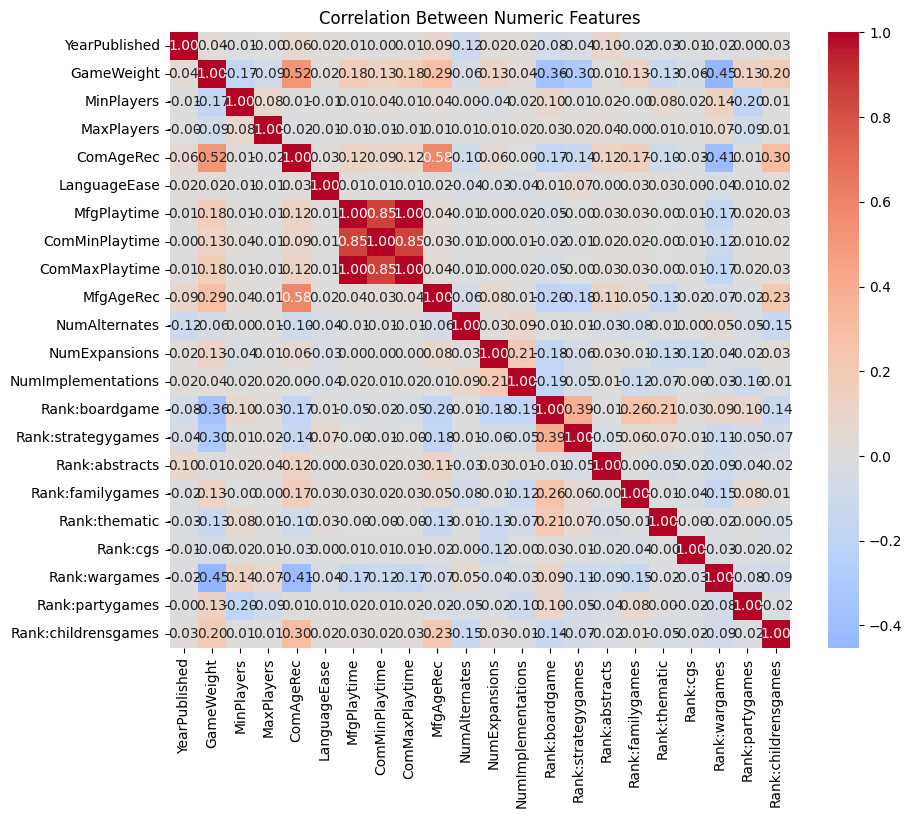

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Between Numeric Features")
plt.show()

#### Decision: Feature Refinement

- **Remove `Rank:*` columns** - derived from ratings and introduce leakage
- **Remove `MfgAgeRec`** - already applied to impute missing `ComAgeRec`
- **Remove `MfgPlaytime`** - strong correlation with community playtime features

In [ ]:
# Drop rank columns (avoid data leakage)
rank_cols = [col for col in df_model.columns if "Rank:" in col]

df_model = df_model.drop(columns=rank_cols)

# Drop manufacturer age recommendation and play time
df_model = df_model.drop(columns=["MfgAgeRec", "MfgPlaytime"], errors="ignore")

In [37]:
df_model.shape

(21925, 405)

## Define final modelling dataset

In [39]:
# X = final cleaned feature set
X = df_model.copy()

# y = target variable from the merged dataset
y = df["BayesAvgRating"].copy()

In [40]:
# ---------- Final sanity checks ----------
# Check row counts match
assert len(X) == len(y), "X and y have different numbers of rows!"

# Check no missing values remain in X
assert X.isna().sum().sum() == 0, "Missing values still remain in X!"

# Check all X columns are numeric
assert len(X.select_dtypes(include="object").columns) == 0, "Object columns still remain in X!"


# ---------- Create output folder ----------
output_dir = Path("../data")
output_dir.mkdir(parents=True, exist_ok=True)


# ---------- Save outputs ----------
# Save feature matrix
X.to_csv(output_dir / "X.csv", index=False)

# Save target as a one-column CSV
y.to_csv(output_dir / "y.csv", index=False)


# ---------- Save feature names for reference ----------
feature_names = pd.DataFrame({"feature": X.columns})
feature_names.to_csv(output_dir / "feature_names.csv", index=False)


# ---------- Confirm files saved ----------
print("Saved files:")
print(output_dir / "X.csv")
print(output_dir / "y.csv")
print(output_dir / "feature_names.csv")
print()
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Saved files:
../data/X.csv
../data/y.csv
../data/feature_names.csv

X shape: (21925, 405)
y shape: (21925,)
